In [1]:
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/졸업 과제/dataset/processing/final_dataset.csv'

Mounted at /content/drive


In [2]:
!pip install pytorch-tcn

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from pytorch_tcn import TCN
import os

# 1. 데이터 로딩 및 정제 함수
def load_and_prepare_data(file_path, window_size=60, usage_ratio=0.95):
    print(f"데이터 로드 중... ({file_path})")
    df = pd.read_csv(file_path)

    # [정렬 보장] 영상별, 시간 순서대로 정렬
    df = df.sort_values(['video_id', 'frame']).reset_index(drop=True)

    # [95% 추출] 비디오 ID 기준 샘플링
    unique_videos = df['video_id'].unique()
    num_use = int(len(unique_videos) * usage_ratio)
    selected_videos = unique_videos[:num_use]
    df = df[df['video_id'].isin(selected_videos)].reset_index(drop=True)

    # 피처 정의 (좌표 51개 + 특징 4개 = 55개)
    kp_cols = [c for c in df.columns if 'kp' in c]
    eng_cols = ['HSSC_y', 'HSSC_x', 'RWHC', 'VHSSC']
    feature_cols = kp_cols + eng_cols

    print(f"사용 비디오: {len(selected_videos)}개 / 총 피처: {len(feature_cols)}개")
    return df, feature_cols

# 2. 영상 단위 구분을 보장하는 데이터셋 클래스
class FallDataset(Dataset):
    def __init__(self, df, feature_cols, window_size=60, is_train=True):
        self.window_size = window_size
        self.feature_cols = feature_cols
        self.valid_indices = []

        # 전체 데이터를 텐서로 변환 (속도 향상)
        self.all_features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.all_labels = torch.tensor(df['label'].values, dtype=torch.long)

        # 영상별 경계 구분 및 불균형 해소 샘플링
        current_offset = 0
        for v_id, group in df.groupby('video_id'):
            v_len = len(group)
            labels = group['label'].values

            for i in range(v_len - window_size + 1):
                # 윈도우의 마지막 프레임이 낙상(1)인지 확인
                is_fall = labels[i + window_size - 1] == 1

                if is_train:
                    if is_fall: # 낙상 구간: 전부 포함 (Stride 1)
                        self.valid_indices.append(current_offset + i)
                    elif i % 5 == 0: # 정상 구간: 5프레임마다 하나씩 (Stride 5)
                        self.valid_indices.append(current_offset + i)
                else: # 검증용: 모든 프레임 확인
                    self.valid_indices.append(current_offset + i)
            current_offset += v_len

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start_ptr = self.valid_indices[idx]
        # TCN 입력 형태: (Channels, Time) -> (55, 60)
        x = self.all_features[start_ptr : start_ptr + self.window_size].T
        y = self.all_labels[start_ptr + self.window_size - 1]
        return x, y

# 3. 메인 학습 프로세스
def run_training(file_path, epochs=20, batch_size=128):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    window_size = 60 # 15fps * 4초

    # 데이터 준비
    df, feature_cols = load_and_prepare_data(file_path, window_size, usage_ratio=0.95)

    # 클래스 가중치 계산 (Loss 보정)
    counts = df['label'].value_counts()
    weight_val = counts[0] / counts[1]
    class_weights = torch.tensor([1.0, weight_val], dtype=torch.float32).to(device)

    # 비디오 단위 분할 (학습 80% : 검증 20%)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(gss.split(df, groups=df['video_id']))

    train_ds = FallDataset(df.iloc[train_idx], feature_cols, window_size, is_train=True)
    val_ds = FallDataset(df.iloc[val_idx], feature_cols, window_size, is_train=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # 모델 정의
    model = TCN(
    num_inputs=len(feature_cols),
    num_channels=[64, 64, 128, 2],
    kernel_size=3,
    dropout=0.2,
    causal=True
).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # 학습 루프
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            logits = output[:, :, -1] # [Batch, 2, 60] -> [Batch, 2]로 추출
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # 검증 루프
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                logits = output[:, :, -1]
                pred = logits.argmax(dim=1)
                val_correct += (pred == y).sum().item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_correct/len(val_ds):.4f}")

    # 모델 저장
    torch.save(model.state_dict(), "fall_detection_model.pth")
    print("모델 저장 완료: fall_detection_model.pth")

# 실행 지점
if __name__ == "__main__":
    CSV_PATH = file_path # 파일 경로 수정
    run_training(CSV_PATH)

데이터 로드 중... (/content/drive/MyDrive/졸업 과제/dataset/processing/final_dataset.csv)
사용 비디오: 19361개 / 총 피처: 55개
Epoch 1/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 2/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 3/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 4/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 5/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 6/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 7/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 8/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 9/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 10/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 11/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 12/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 13/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 14/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 15/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 16/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 17/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 18/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 19/20 | Loss: 0.6931 | Val Acc: 0.8961
Epoch 20/20 | Loss: 0.6931 | Val Acc: 0.8961
모델

In [4]:
import json
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

def test_unseen_data(file_path, model_path, window_size=60, usage_ratio=0.95):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. 데이터 로드 및 5% 테스트 데이터만 추출
    df = pd.read_csv(file_path)
    df = df.sort_values(['video_id', 'frame']).reset_index(drop=True)

    unique_videos = df['video_id'].unique()
    num_train_val = int(len(unique_videos) * usage_ratio)
    # 학습에 사용되지 않은 나머지 5% 비디오 선택
    test_videos = unique_videos[num_train_val:]

    test_df = df[df['video_id'].isin(test_videos)].reset_index(drop=True)
    print(f"테스트용 미사용 비디오 개수: {len(test_videos)}개")

    # 2. 피처 설정 및 데이터셋 생성
    kp_cols = [c for c in test_df.columns if 'kp' in c]
    eng_cols = ['HSSC_y', 'HSSC_x', 'RWHC', 'VHSSC']
    feature_cols = kp_cols + eng_cols

    # 테스트 시에는 모든 프레임을 다 확인해야 하므로 is_train=False
    test_ds = FallDataset(test_df, feature_cols, window_size, is_train=False)
    test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

    # 3. 모델 로드
    model = TCN(
        num_inputs=len(feature_cols),
        num_channels=[64, 64, 128, 2],
        kernel_size=3,
        dropout=0.2,
        causal=True
    ).to(device)

    model.load_state_dict(torch.load(model_path))
    model.eval()

    # 4. 추론 및 성능 지표 계산
    all_preds = []
    all_targets = []
    all_probs = [] # Add this to store probabilities for ROC curve

    print("미사용 데이터로 테스트 시작...")
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            logits = output[:, :, -1]
            probs = torch.softmax(logits, dim=1)[:, 1] # Probability of class 1 (Fall)
            pred = logits.argmax(dim=1)

            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # 5. 결과 출력
    print("\n[테스트 결과 보고서]")
    print(classification_report(all_targets, all_preds, target_names=['Normal', 'Fall']))

    return all_targets, all_preds, all_probs

# # 실행 (학습 완료 후 진행)
# test_unseen_data(CSV_PATH, "fall_detection_model.pth")

In [5]:
def run_multiple_verifications(model, file_path, num_videos=5, usage_ratio=0.95, threshold=0.5):
    # 1. 데이터 로드 및 미사용 데이터(5%) 분리
    df = pd.read_csv(file_path)
    df = df.sort_values(['video_id', 'frame']).reset_index(drop=True)

    unique_videos = df['video_id'].unique()
    num_train_val = int(len(unique_videos) * usage_ratio)
    unseen_videos = unique_videos[num_train_val:] # 금고 속 5% 비디오들

    # 2. 피처 컬럼 정의
    kp_cols = [c for c in df.columns if 'kp' in c]
    eng_cols = ['HSSC_y', 'HSSC_x', 'RWHC', 'VHSSC']
    feature_cols = kp_cols + eng_cols

    # 3. 테스트 비디오 선정 (낙상이 있는 영상과 없는 영상을 골고루 확인)
    # 팁: 단순히 랜덤하게 뽑기보다, 낙상 라벨(1)이 포함된 영상을 우선적으로 보면 좋습니다.
    fall_videos = df[(df['video_id'].isin(unseen_videos)) & (df['label'] == 1)]['video_id'].unique()
    normal_videos = list(set(unseen_videos) - set(fall_videos))

    print(f"미사용 영상 중 낙상 포함: {len(fall_videos)}개, 정상만 포함: {len(normal_videos)}개")

    # 보고 싶은 영상 ID 리스트 (낙상 영상 3개 + 정상 영상 2개 등)
    target_ids = list(fall_videos[:3]) + list(normal_videos[:2])

    # 4. 루프 돌며 시각화 실행
    for v_id in target_ids:
        print(f"\n[분석 중] 비디오 ID: {v_id}")
        verify_video_prediction(model, df, v_id, feature_cols, threshold=threshold)

# 실행
# run_multiple_verifications(model, CSV_PATH, num_videos=5, threshold=0.7)

In [6]:
def load_model(model_path, n_features=55):
    model = TCN(
        num_inputs=n_features,
        num_channels=[64, 64, 128, 2],
        kernel_size=3,
        dropout=0.2,
        causal=True
    ).cuda()
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model

In [7]:
import matplotlib.pyplot as plt
import torch
import pandas as pd
import numpy as np

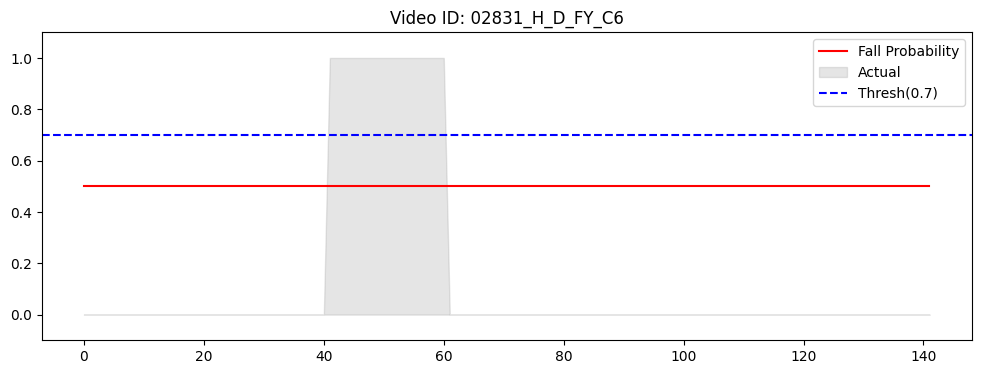

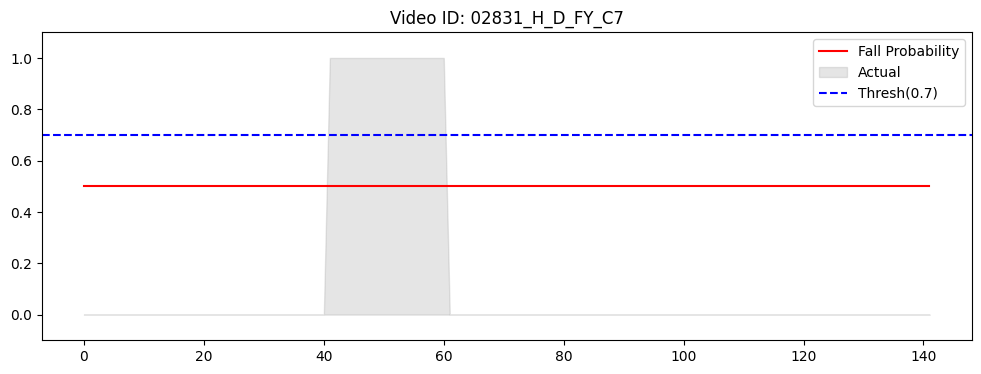

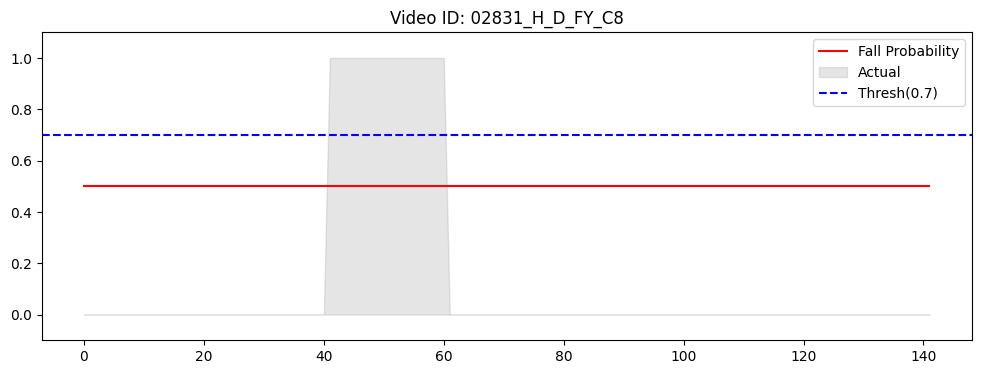

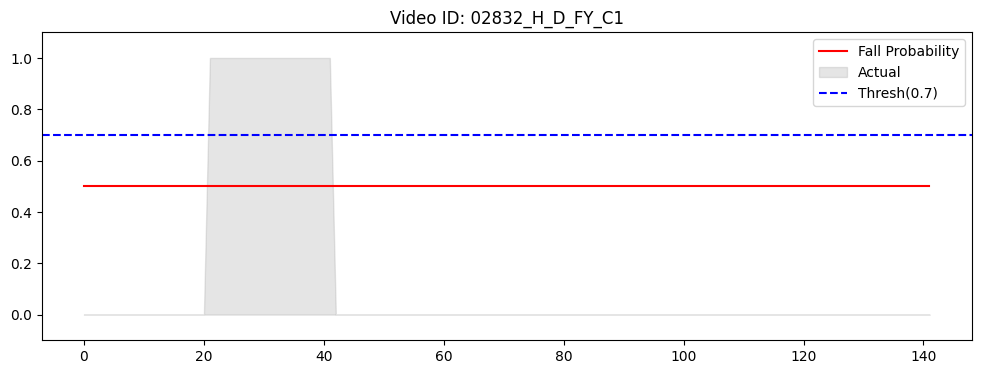

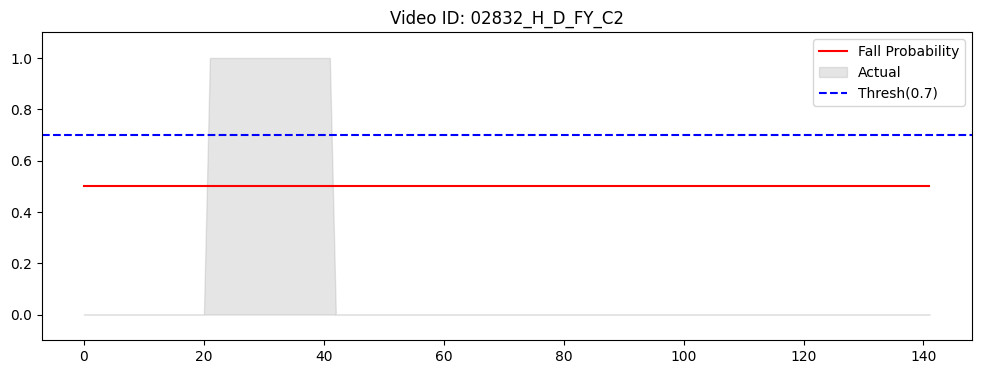

In [10]:
def get_video_windows(df, video_id, feature_cols, window_size=60):
    video_data = df[df['video_id'] == video_id].sort_values('frame')
    features = video_data[feature_cols].values
    labels = video_data['label'].values
    windows = []
    actual_labels = []
    for i in range(len(features) - window_size + 1):
        windows.append(features[i:i+window_size])
        actual_labels.append(labels[i+window_size-1])
    return np.array(windows), np.array(actual_labels)

def verify_video_prediction(model, df, video_id, feature_cols, threshold=0.5):
    windows, actuals = get_video_windows(df, video_id, feature_cols)
    if len(windows) == 0:
        print(f"ID {video_id}: 데이터가 부족합니다.")
        return

    input_tensor = torch.tensor(windows, dtype=torch.float32).transpose(1, 2).cuda()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output[:, :, -1], dim=1)[:, 1].cpu().numpy()

    plt.figure(figsize=(12, 4))
    plt.plot(probs, label='Fall Probability', color='red')
    plt.fill_between(range(len(actuals)), actuals, alpha=0.2, color='gray', label='Actual')
    plt.axhline(y=threshold, color='blue', linestyle='--', label=f'Thresh({threshold})')
    plt.title(f"Video ID: {video_id}")
    plt.ylim(-0.1, 1.1)
    plt.legend()
    plt.show()

def run_multiple_verifications(model, file_path, num_videos=5, usage_ratio=0.95, threshold=0.5):
    # 1. 데이터 로드 및 미사용 데이터(5%) 분리
    df = pd.read_csv(file_path)
    df = df.sort_values(['video_id', 'frame']).reset_index(drop=True)
    unique_videos = df['video_id'].unique()
    num_train_val = int(len(unique_videos) * usage_ratio)
    unseen_videos = unique_videos[num_train_val:]

    # 2. 피처 컬럼 정의
    kp_cols = [c for c in df.columns if 'kp' in c]
    eng_cols = ['HSSC_y', 'HSSC_x', 'RWHC', 'VHSSC']
    feature_cols = kp_cols + eng_cols

    # 3. 테스트 비디오 선정
    fall_videos = df[(df['video_id'].isin(unseen_videos)) & (df['label'] == 1)]['video_id'].unique()

    # 보고 싶은 비디오 개수 조절
    target_ids = list(fall_videos[:num_videos])

    for v_id in target_ids:
        verify_video_prediction(model, df, v_id, feature_cols, threshold=threshold)


MODEL_PATH = "fall_detection_model.pth"

model = load_model(MODEL_PATH) # 이전에 정의한 load_model 함수 사용
run_multiple_verifications(model, file_path, num_videos=5, threshold=0.7)